In [1]:
# =========================================================
# STEP 1 — Load images, preprocess, normalize, and split
# =========================================================
import os, random, numpy as np, cv2, tensorflow as tf, matplotlib.pyplot as plt, seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix,
                             precision_recall_fscore_support, cohen_kappa_score, roc_auc_score)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import Xception

# Set reproducible seed values
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Mount Google Drive (needed in Colab)
drive.mount('/content/drive')

# Define dataset folder paths
dataset_root = '/content/drive/MyDrive/PlantDoc-Dataset'
train_dir = f'{dataset_root}/train'
test_dir  = f'{dataset_root}/test'

# ---------------------------------------------------------
# Function to load all images and labels from dir structure
# ---------------------------------------------------------
def load_plantdoc_data(data_dir, img_size=(299, 299)):
    X, y = [], []
    class_names = sorted([d for d in os.listdir(data_dir)
                          if os.path.isdir(os.path.join(data_dir, d))])
    class_to_idx = {cls: i for i, cls in enumerate(class_names)}
    for cls in class_names:
        cls_dir = os.path.join(data_dir, cls)
        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:  # skip unreadable files
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)
            X.append(img)
            y.append(class_to_idx[cls])
    return np.array(X, np.float32), np.array(y, np.int32), class_names

# Load training & testing sets from folders
X_train, y_train, class_names = load_plantdoc_data(train_dir)
X_test,  y_test,  _           = load_plantdoc_data(test_dir)
num_classes = len(class_names)

# Normalize pixel values to [0,1]
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Split data into Train + Validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED
)

# Convert integer labels → one-hot encoded form
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Mounted at /content/drive
Train: (1852, 299, 299, 3), Val: (464, 299, 299, 3), Test: (236, 299, 299, 3)


In [2]:
# =========================================================
# STEP 2 — Compute class weights to balance class imbalance
# =========================================================
class_weights = compute_class_weight(
    class_weight='balanced', classes=np.arange(num_classes), y=y_train
)
class_weights = {i: w for i, w in enumerate(class_weights)}
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.1063321385902032), 1: np.float64(1.0392817059483725), 2: np.float64(1.0887713109935333), 3: np.float64(1.6331569664902998), 4: np.float64(1.3718518518518519), 5: np.float64(0.8165784832451499), 6: np.float64(1.8050682261208577), 7: np.float64(1.3449527959331882), 8: np.float64(0.4763374485596708), 9: np.float64(0.8069716775599128), 10: np.float64(0.8364950316169828), 11: np.float64(0.7884206045125586), 12: np.float64(0.879392212725546), 13: np.float64(0.7884206045125586), 14: np.float64(1.4911433172302737), 15: np.float64(0.6999244142101285), 16: np.float64(0.9798941798941799), 17: np.float64(1.162586315128688), 18: np.float64(0.6292898402990146), 19: np.float64(1.595176571920758), 20: np.float64(0.879392212725546), 21: np.float64(0.846822130772748), 22: np.float64(1.9597883597883599), 23: np.float64(1.247138047138047), 24: np.float64(1.008714596949891), 25: np.float64(1.4911433172302737), 26: np.float64(1.5242798353909466)}


In [3]:
# =========================================================
# STEP 3 — Custom callback to monitor validation Cohen’s Kappa
# =========================================================
class KappaCallback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val_cat):
        super().__init__()
        self.X_val = X_val
        self.y_val_cat = y_val_cat

    def on_epoch_end(self, epoch, logs=None):
        # Predict class probabilities on validation set
        y_val_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        y_val_true = np.argmax(self.y_val_cat, axis=1)
        # Calculate Cohen’s Kappa metric
        kappa = cohen_kappa_score(y_val_true, y_val_pred)
        val_acc = logs.get("val_accuracy")
        # Display both metrics immediately after each epoch
        print(f"\nEpoch {epoch+1} → Val.Acc: {val_acc:.4f} | Kappa: {kappa:.4f}")

In [4]:
# 📦 Install Keras Tuner (official AutoML hyperparameter tuner for Keras)
!pip install keras-tuner --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 5.7 MB/s eta 0:00:00


In [5]:
# =========================================================
# STEP 4 — Build an Xception model with tunable hyperparams
#         and unfreeze layers 5–40 of the base network
# =========================================================
from keras_tuner import HyperModel

class XceptionHyperModel(HyperModel):
    def __init__(self, num_classes, input_shape=(299,299,3)):
        self.num_classes = num_classes
        self.input_shape = input_shape

    def build(self, hp):
        # Define hyperparameters to tune
        dropout = hp.Choice('dropout', [0.3, 0.4, 0.5])
        lr = hp.Float('lr', 1e-5, 1e-3, sampling='log')
        optimizer_choice = hp.Choice('optimizer', ['adam', 'rmsprop', 'sgd'])

        # Basic on‑the‑fly augmentation
        aug = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.1),
            layers.RandomContrast(0.1)
        ], name="augment")

        # ---------------------------------------------------------
        # Load Xception base, unfreeze only layers 5–40
        # ---------------------------------------------------------
        base = Xception(include_top=False, weights='imagenet',
                        input_shape=self.input_shape)

        # First freeze everything as a safety default
        for layer in base.layers:
            layer.trainable = False

        # Then selectively unfreeze region [5:40]
        for layer in base.layers[5:41]:
            layer.trainable = True

        # Build classification head on top of base
        inputs = layers.Input(shape=self.input_shape)
        x = aug(inputs)
        x = base(x, training=False)       # base runs with some layers trainable
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(dropout)(x)
        x = layers.Dense(512, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        model = models.Model(inputs, outputs)

        # Optimizer mapping for tuner choice
        opt_map = {
            'adam'   : optimizers.Adam(learning_rate=lr),
            'rmsprop': optimizers.RMSprop(learning_rate=lr),
            'sgd'    : optimizers.SGD(learning_rate=lr, momentum=0.9)
        }

        # Compile the model
        loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)
        model.compile(optimizer=opt_map[optimizer_choice],
                      loss=loss, metrics=['accuracy'])

        # Print verification line so you know which layers are trainable
        print(f"Unfrozen layers: ", [l.name for l in base.layers[5:41]])
        return model

In [6]:
# =========================================================
# STEP 5 — Keras Tuner search for best lr, optimizer, dropout, AND batch size
# =========================================================
# Make sure you have: !pip install keras-tuner -q
import keras_tuner as kt

# ---------------------------------------------------------
# 1️⃣ Define model builder for tuner
# ---------------------------------------------------------
def model_builder(hp):
    """
    Build Xception model for each tuner trial using supplied hyperparameters.
    Batch size will also be stored inside `hp` so we can access it later.
    """
    # Add batch size as a tunable hyperparameter so it's stored in hp
    hp.Choice('batch_size', [16, 32, 64])

    # Build your HyperModel as usual (tunes lr, optimizer, dropout)
    return XceptionHyperModel(num_classes).build(hp)

# ---------------------------------------------------------
# 2️⃣ Initialize Bayesian Optimization tuner
# ---------------------------------------------------------
tuner = kt.BayesianOptimization(
    model_builder,
    objective='val_accuracy',                         # maximize validation acc
    max_trials=10,                                   # number of different combos
    executions_per_trial=1,                          # one run per config
    directory='/content/drive/MyDrive/XceptionTuner',# output directory
    project_name='xception_tuning'                   # unique subfolder
)

# Show the search space to confirm
tuner.search_space_summary()

# ---------------------------------------------------------
# 3️⃣ Run the actual hyperparameter search
# ---------------------------------------------------------
# Keras Tuner automatically passes each trial’s hp (containing batch_size)
tuner.search(
    X_train, y_train_cat,                            # training data
    validation_data=(X_val, y_val_cat),              # validation data
    epochs=5,                                        # short runs for tuning
    class_weight=class_weights,                      # handle class imbalance
    callbacks=[KappaCallback(X_val, y_val_cat)],     # show kappa each epoch
    verbose=1
)

# ---------------------------------------------------------
# 4️⃣ Retrieve & display best hyperparameters found
# ---------------------------------------------------------
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n🎯 Best Hyperparameters Found:")
print(f" Learning Rate: {best_hp.get('lr')}")
print(f" Optimizer:    {best_hp.get('optimizer')}")
print(f" Dropout:     {best_hp.get('dropout')}")
print(f" Batch Size:   {best_hp.get('batch_size')}")

# Optional summary of top trials
tuner.results_summary(num_trials=3)

Trial 10 Complete [00h 05m 55s]
val_accuracy: 0.32758620381355286

Best val_accuracy So Far: 0.48275861144065857
Total elapsed time: 05h 55m 42s

🎯 Best Hyperparameters Found:
 Learning Rate: 0.00038017118026419686
 Optimizer:    adam
 Dropout:     0.4
 Batch Size:   32
Results summary
Results in /content/drive/MyDrive/XceptionTuner/xception_tuning
Showing 3 best trials
Objective(name="val_accuracy", direction="max")

Trial 03 summary
Hyperparameters:
dropout: 0.4
lr: 0.00038017118026419686
optimizer: adam
batch_size: 32
Score: 0.48275861144065857

Trial 05 summary
Hyperparameters:
dropout: 0.3
lr: 6.172163801946591e-05
optimizer: rmsprop
batch_size: 16
Score: 0.4288793206214905

Trial 09 summary
Hyperparameters:
dropout: 0.4
lr: 0.00029902169136739786
optimizer: sgd
batch_size: 64
Score: 0.32758620381355286


In [7]:
# =========================================================
# STEP 6 — Retrain best model (warmup + fine-tune combined)
# =========================================================
# Build model using best hyperparameters
best_model = tuner.hypermodel.build(best_hp)

# Define callbacks for proper validation monitoring
callbacks_best = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                     restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.3,
                                         patience=3, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint('/content/best_xception_tuned.keras',
                                       save_best_only=True,
                                       monitor='val_accuracy', verbose=1),
    KappaCallback(X_val, y_val_cat)
]

# Train model with full epochs using tuned hyperparameters
history_best = best_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=20,
    batch_size=best_hp.get('batch_size'),
    class_weight=class_weights,
    callbacks=callbacks_best,
    verbose=1
)

# Save final best model to Drive
best_model.save('/content/drive/MyDrive/XceptionTuner/final_best_model.keras')

Unfrozen layers:  ['block1_conv2_bn', 'block1_conv2_act', 'block2_sepconv1', 'block2_sepconv1_bn', 'block2_sepconv2_act', 'block2_sepconv2', 'block2_sepconv2_bn', 'conv2d_4', 'block2_pool', 'batch_normalization_5', 'add_12', 'block3_sepconv1_act', 'block3_sepconv1', 'block3_sepconv1_bn', 'block3_sepconv2_act', 'block3_sepconv2', 'block3_sepconv2_bn', 'conv2d_5', 'block3_pool', 'batch_normalization_6', 'add_13', 'block4_sepconv1_act', 'block4_sepconv1', 'block4_sepconv1_bn', 'block4_sepconv2_act', 'block4_sepconv2', 'block4_sepconv2_bn', 'conv2d_6', 'block4_pool', 'batch_normalization_7', 'add_14', 'block5_sepconv1_act', 'block5_sepconv1', 'block5_sepconv1_bn', 'block5_sepconv2_act', 'block5_sepconv2']
Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accuracy: 0.1043 - loss: 3.9851
Epoch 1: val_accuracy improved from -inf to 0.34267, saving model to /content/best_xception_tuned.keras

Epoch 1 → Val.Acc: 0.3427 | Kappa: 0.3151
58/58 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.105

In [8]:
# =========================================================
# STEP 7 — Evaluate tuned model on unseen test images
# =========================================================
model = tf.keras.models.load_model('/content/drive/MyDrive/XceptionTuner/final_best_model.keras')

# Predict probabilities for entire test set
y_pred_proba = model.predict(X_test, verbose=0)
# Convert probabilities → discrete class predictions
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test

# Compute performance metrics
acc   = accuracy_score(y_true, y_pred)
f1w   = f1_score(y_true, y_pred, average='weighted')
kappa = cohen_kappa_score(y_true, y_pred)

print(f"\n📊 Test Evaluation:")
print(f" Accuracy:      {acc:.4f}")
print(f" Weighted F1:   {f1w:.4f}")
print(f" Cohen's Kappa: {kappa:.4f}")


📊 Test Evaluation:
 Accuracy:      0.5805
 Weighted F1:   0.5750
 Cohen's Kappa: 0.5640


In [9]:
# =========================================================
# STEP 8 — Post-training quantization (FP32 ⚙→ INT8)
# =========================================================
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # enables INT8 quantization
tflite_model_int8 = converter.convert()

# Save quantized INT8 model
int8_path = "/content/drive/MyDrive/XceptionTuner/xception_int8.tflite"
with open(int8_path, "wb") as f:
    f.write(tflite_model_int8)
print("✅ INT8 model saved at:", int8_path)

# Evaluate INT8 model manually using TensorFlow Lite Interpreter
interpreter = tf.lite.Interpreter(model_path=int8_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

y_pred_int8 = []
for img in X_test:
    # Add batch dimension and use float32 input
    img = np.expand_dims(img, axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    y_pred_int8.append(np.argmax(output))
y_pred_int8 = np.array(y_pred_int8)

# Calculate evaluation metrics for INT8 model
acc_int8   = accuracy_score(y_test, y_pred_int8)
f1w_int8   = f1_score(y_test, y_pred_int8, average='weighted')
kappa_int8 = cohen_kappa_score(y_test, y_pred_int8)

print("\n📦 INT8 Quantized Model Evaluation:")
print(f" Accuracy:      {acc_int8:.4f}")
print(f" Weighted F1:   {f1w_int8:.4f}")
print(f" Cohen's Kappa: {kappa_int8:.4f}")

Saved artifact at '/tmp/tmpfh_a02eb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 27), dtype=tf.float32, name=None)
Captures:
  140571696519248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696516752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696517328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696515600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696518288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696519440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696513104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696514256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696519632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696520592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696518

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



📦 INT8 Quantized Model Evaluation:
 Accuracy:      0.5636
 Weighted F1:   0.5589
 Cohen's Kappa: 0.5465


In [10]:
# =========================================================
# STEP 9 — Show model sizes for FP32 and INT8 variants
# =========================================================
def tflite_summary(path):
    size_mb = os.path.getsize(path) / (1024*1024)
    print(f"{os.path.basename(path)} → {size_mb:.2f} MB")

# Create also a FP32 TFLite model for comparison
fp32_path = "/content/drive/MyDrive/XceptionTuner/xception_fp32.tflite"
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model_fp32 = converter.convert()
with open(fp32_path, "wb") as f:
    f.write(tflite_model_fp32)

tflite_summary(fp32_path)
tflite_summary(int8_path)

Saved artifact at '/tmp/tmpmq_r4bc_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 27), dtype=tf.float32, name=None)
Captures:
  140571696519248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696516752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696517328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696515600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696518288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696519440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696513104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696514256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696519632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696520592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571696518

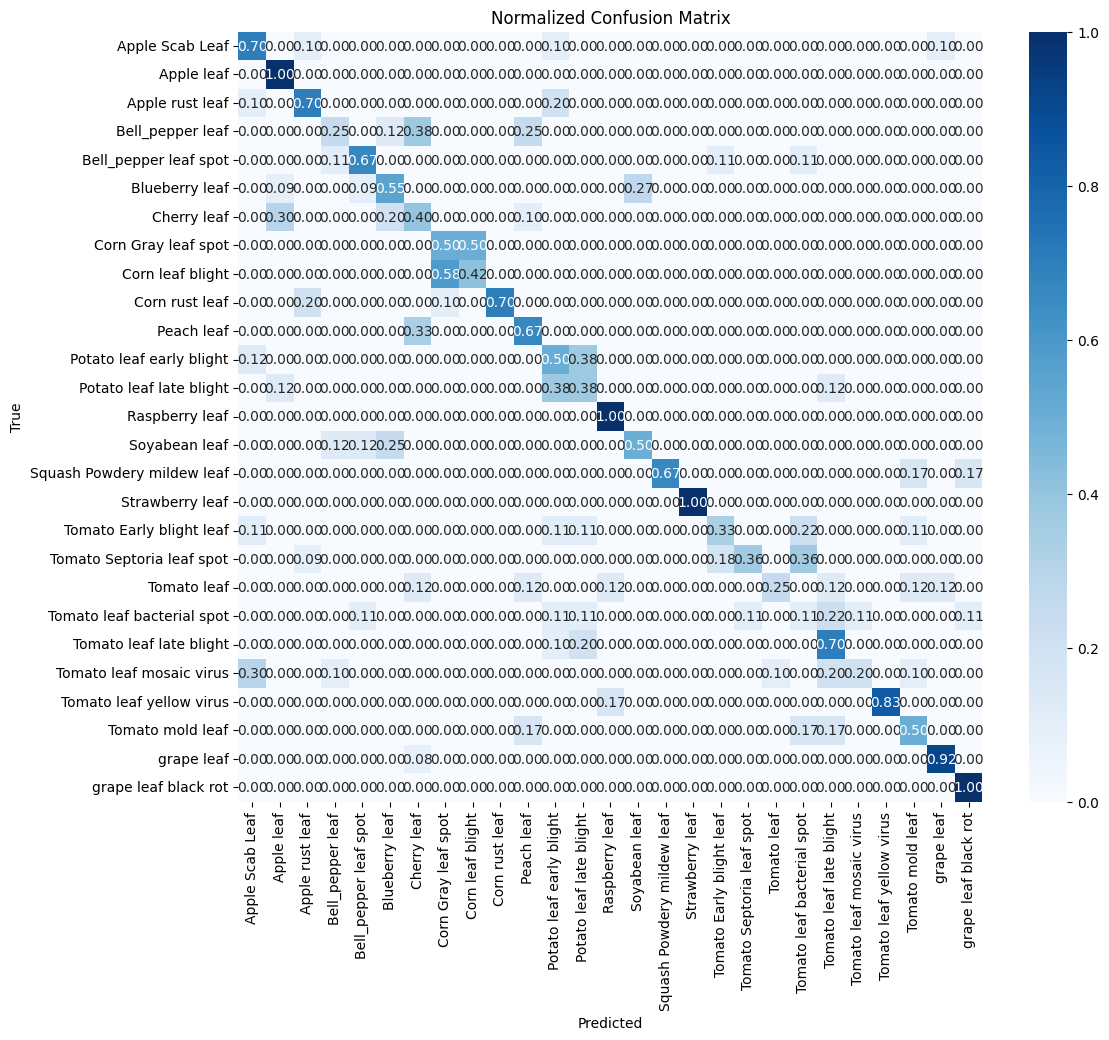

Apple Scab Leaf           | Precision: 0.538, Recall: 0.700, F1: 0.609, Support: 10
Apple leaf                | Precision: 0.643, Recall: 1.000, F1: 0.783, Support: 9
Apple rust leaf           | Precision: 0.636, Recall: 0.700, F1: 0.667, Support: 10
Bell_pepper leaf          | Precision: 0.400, Recall: 0.250, F1: 0.308, Support: 8
Bell_pepper leaf spot     | Precision: 0.667, Recall: 0.667, F1: 0.667, Support: 9
Blueberry leaf            | Precision: 0.545, Recall: 0.545, F1: 0.545, Support: 11
Cherry leaf               | Precision: 0.333, Recall: 0.400, F1: 0.364, Support: 10
Corn Gray leaf spot       | Precision: 0.200, Recall: 0.500, F1: 0.286, Support: 4
Corn leaf blight          | Precision: 0.714, Recall: 0.417, F1: 0.526, Support: 12
Corn rust leaf            | Precision: 1.000, Recall: 0.700, F1: 0.824, Support: 10
Peach leaf                | Precision: 0.545, Recall: 0.667, F1: 0.600, Support: 9
Potato leaf early blight  | Precision: 0.308, Recall: 0.500, F1: 0.381, Support: 

In [11]:
# =========================================================
# STEP 10 — Visualize confusion matrix and per-class metrics
# =========================================================
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12,10))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()

# Compute precision, recall, F1 for each class
p, r, f, s = precision_recall_fscore_support(
    y_true, y_pred, labels=np.arange(num_classes)
)
for i, cls in enumerate(class_names):
    print(f"{cls:25s} | Precision: {p[i]:.3f}, Recall: {r[i]:.3f}, "
          f"F1: {f[i]:.3f}, Support: {s[i]}")